Цель: Научиться применять методы предобработки данных на реальном датасете, оценивать их влияние на качество модели и понимать важность каждого этапа.

Дтасет Bank Marketing Dataset

Ссылка для примера: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing

Целевая переменная: deposit (будет ли клиент открывать депозит).



**Важное условие:** С самого начала разделите исходные данные на обучающую (train) и тестовую (test) выборки в соотношении 80/20. Используйте параметр random_state=42 для воспроизводимости. Все этапы предобработки (заполнение пропусков, кодирование, масштабирование, PCA) должны настраиваться/обучаться ТОЛЬКО на обучающей выборке, а затем применяться к тестовой. Это критически важно для корректной оценки. За основную модель возьмите Random Forest Classifier

1. Базовый анализ (1 балл)

- Загрузите данные, разделите на train/test

- Проведите разведочный анализ данных, посмотрите распределение целевой переменной

- Обучите модель на числовых признаках без обработки (baseline) и на тестовой выборке оцените accuracy


In [190]:
## Импорт библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plta
import statsmodels.api as sm
from sklearn.linear_model import Lasso, Ridge, LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, f1_score, accuracy_score
import statsmodels
from sklearn.preprocessing import StandardScaler

In [191]:
import kagglehub
path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
import os
for file in os.listdir(path):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(path, file), sep=';')
        print(f"Загружен файл: {file}")
        break

Загружен файл: bank-additional-full.csv


In [192]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [193]:
y = df['y']
X = df.drop(['y'], axis = 1)

In [194]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [195]:
X.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


<Axes: xlabel='y', ylabel='Count'>

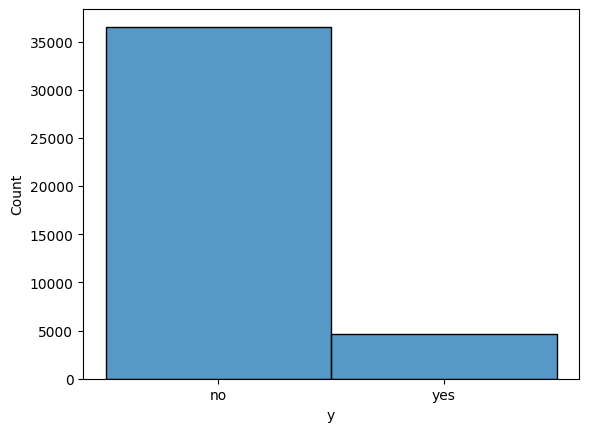

In [196]:
sns.histplot(y, bins = 'auto')

In [197]:
cat_cols = X.select_dtypes(include = 'object').columns.tolist()
X_num = X.drop(cat_cols, axis = 1)
print(X_num.head())

   age  duration  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
0   56       261         1    999         0           1.1          93.994   
1   57       149         1    999         0           1.1          93.994   
2   37       226         1    999         0           1.1          93.994   
3   40       151         1    999         0           1.1          93.994   
4   56       307         1    999         0           1.1          93.994   

   cons.conf.idx  euribor3m  nr.employed  
0          -36.4      4.857       5191.0  
1          -36.4      4.857       5191.0  
2          -36.4      4.857       5191.0  
3          -36.4      4.857       5191.0  
4          -36.4      4.857       5191.0  


In [198]:
X_num_train, X_num_test, y_train, y_test = train_test_split(
                                    X_num, y, random_state=42, stratify=y, test_size=0.2)

In [199]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, random_state = 42, n_jobs=-1)
model_rf.fit(X_num_train, y_train)

y_num_pred = model_rf.predict(X_num_test)

print(f'Accuracy на тестовой выборке = {accuracy_score(y_test, y_num_pred)}')

Accuracy на тестовой выборке = 0.9163631949502307


2. Обработка пропусков (2 балла)

- Найдите и заполните пропуски в train (2 способами):
  - Удаление строк с пропусками
  - Замена пропусков на медиану (для числовых) или моду (для категориальных).

- Обучите модель на данных без пропусков и на тестовой выборке оцените accuracy

In [200]:
df_nulled = df.replace('unknown', np.nan)
df_nulled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             40858 non-null  object 
 2   marital         41108 non-null  object 
 3   education       39457 non-null  object 
 4   default         32591 non-null  object 
 5   housing         40198 non-null  object 
 6   loan            40198 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

#### Заметим, что пропусков в чиcловых данных нет

In [201]:
# Удаление строк с пропусками
df_drop = df_nulled.dropna(axis = 0, how = 'any')
y_drop = df_drop['y']
X_drop = df.drop(['y'], axis = 1)

In [202]:
# заполняем медианой пропуски в числовых данных
X_filled = df_nulled.drop(['y'], axis = 1)

num_cols = X_filled.select_dtypes(include = ['number']).columns

medians = X_filled[num_cols].median()


X_filled[num_cols] = X_filled[num_cols].fillna(medians)


In [203]:
# Заполняем пропуски в категориальных признаках модой
cat_cols = X_filled.select_dtypes(include='object').columns
modes = df_nulled[cat_cols].mode().iloc[0]
X_filled[cat_cols] = X_filled[cat_cols].fillna(modes)


#### Так как нет пропусков в числовых данных, то не имеет смысла еще раз на одинаковых данных считать accuracy 

3. Кодирование категориальных признаков (2 балла)
- Используй данные полученные 2  методом и далее во всех задачах

- Примените Label Encoding и One-Hot Encoding

- Обучите модель с закодированными признаками и на тестовой выборке оцените accuracy



In [204]:
Xf_train, Xf_test, y_train, y_test = train_test_split(
                            X_filled, y, stratify=y, random_state=42, test_size=0.2)

In [205]:
#применяем Label Encoding
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

Xf_train_le = Xf_train.copy()
Xf_test_le = Xf_test.copy()

ord_enc.fit(Xf_train_le[cat_cols])

Xf_train_le[cat_cols] = ord_enc.transform(Xf_train_le[cat_cols])
Xf_test_le[cat_cols] = ord_enc.transform(Xf_test_le[cat_cols])

model_rf_LE = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_LE.fit(Xf_train_le, y_train)

y_pred_le = model_rf_LE.predict(Xf_test_le)

print(f'Accuracy LE: {accuracy_score(y_test, y_pred_le)}')


Accuracy LE: 0.9202476329206118


In [206]:
from sklearn.preprocessing import OneHotEncoder


ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')

ohe.fit(Xf_train[cat_cols])

# Одной строкой: трансформируем категории и приклеиваем к числам
Xf_train_ohe = pd.concat([Xf_train.drop(cat_cols, axis=1), ohe.transform(Xf_train[cat_cols])], axis=1)
Xf_test_ohe  = pd.concat([Xf_test.drop(cat_cols, axis=1),  ohe.transform(Xf_test[cat_cols])],  axis=1)

# Обучение
model_rf_ohe = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_ohe.fit(Xf_train_ohe, y_train)

y_pred_ohe = model_rf_ohe.predict(Xf_test_ohe)


print(f'Accuracy OHE: {accuracy_score(y_test, y_pred_ohe)}')

Accuracy OHE: 0.9163631949502307


4. Обработка выбросов (2 балла )
- Визуализируйте выбросы с помощью boxplot для числовых признаков.

- Примените метод IQR для обнаружения и обработки выбросов .

- Обучите модель на данных без выбросов и на тестовой выборке оцените accuracy


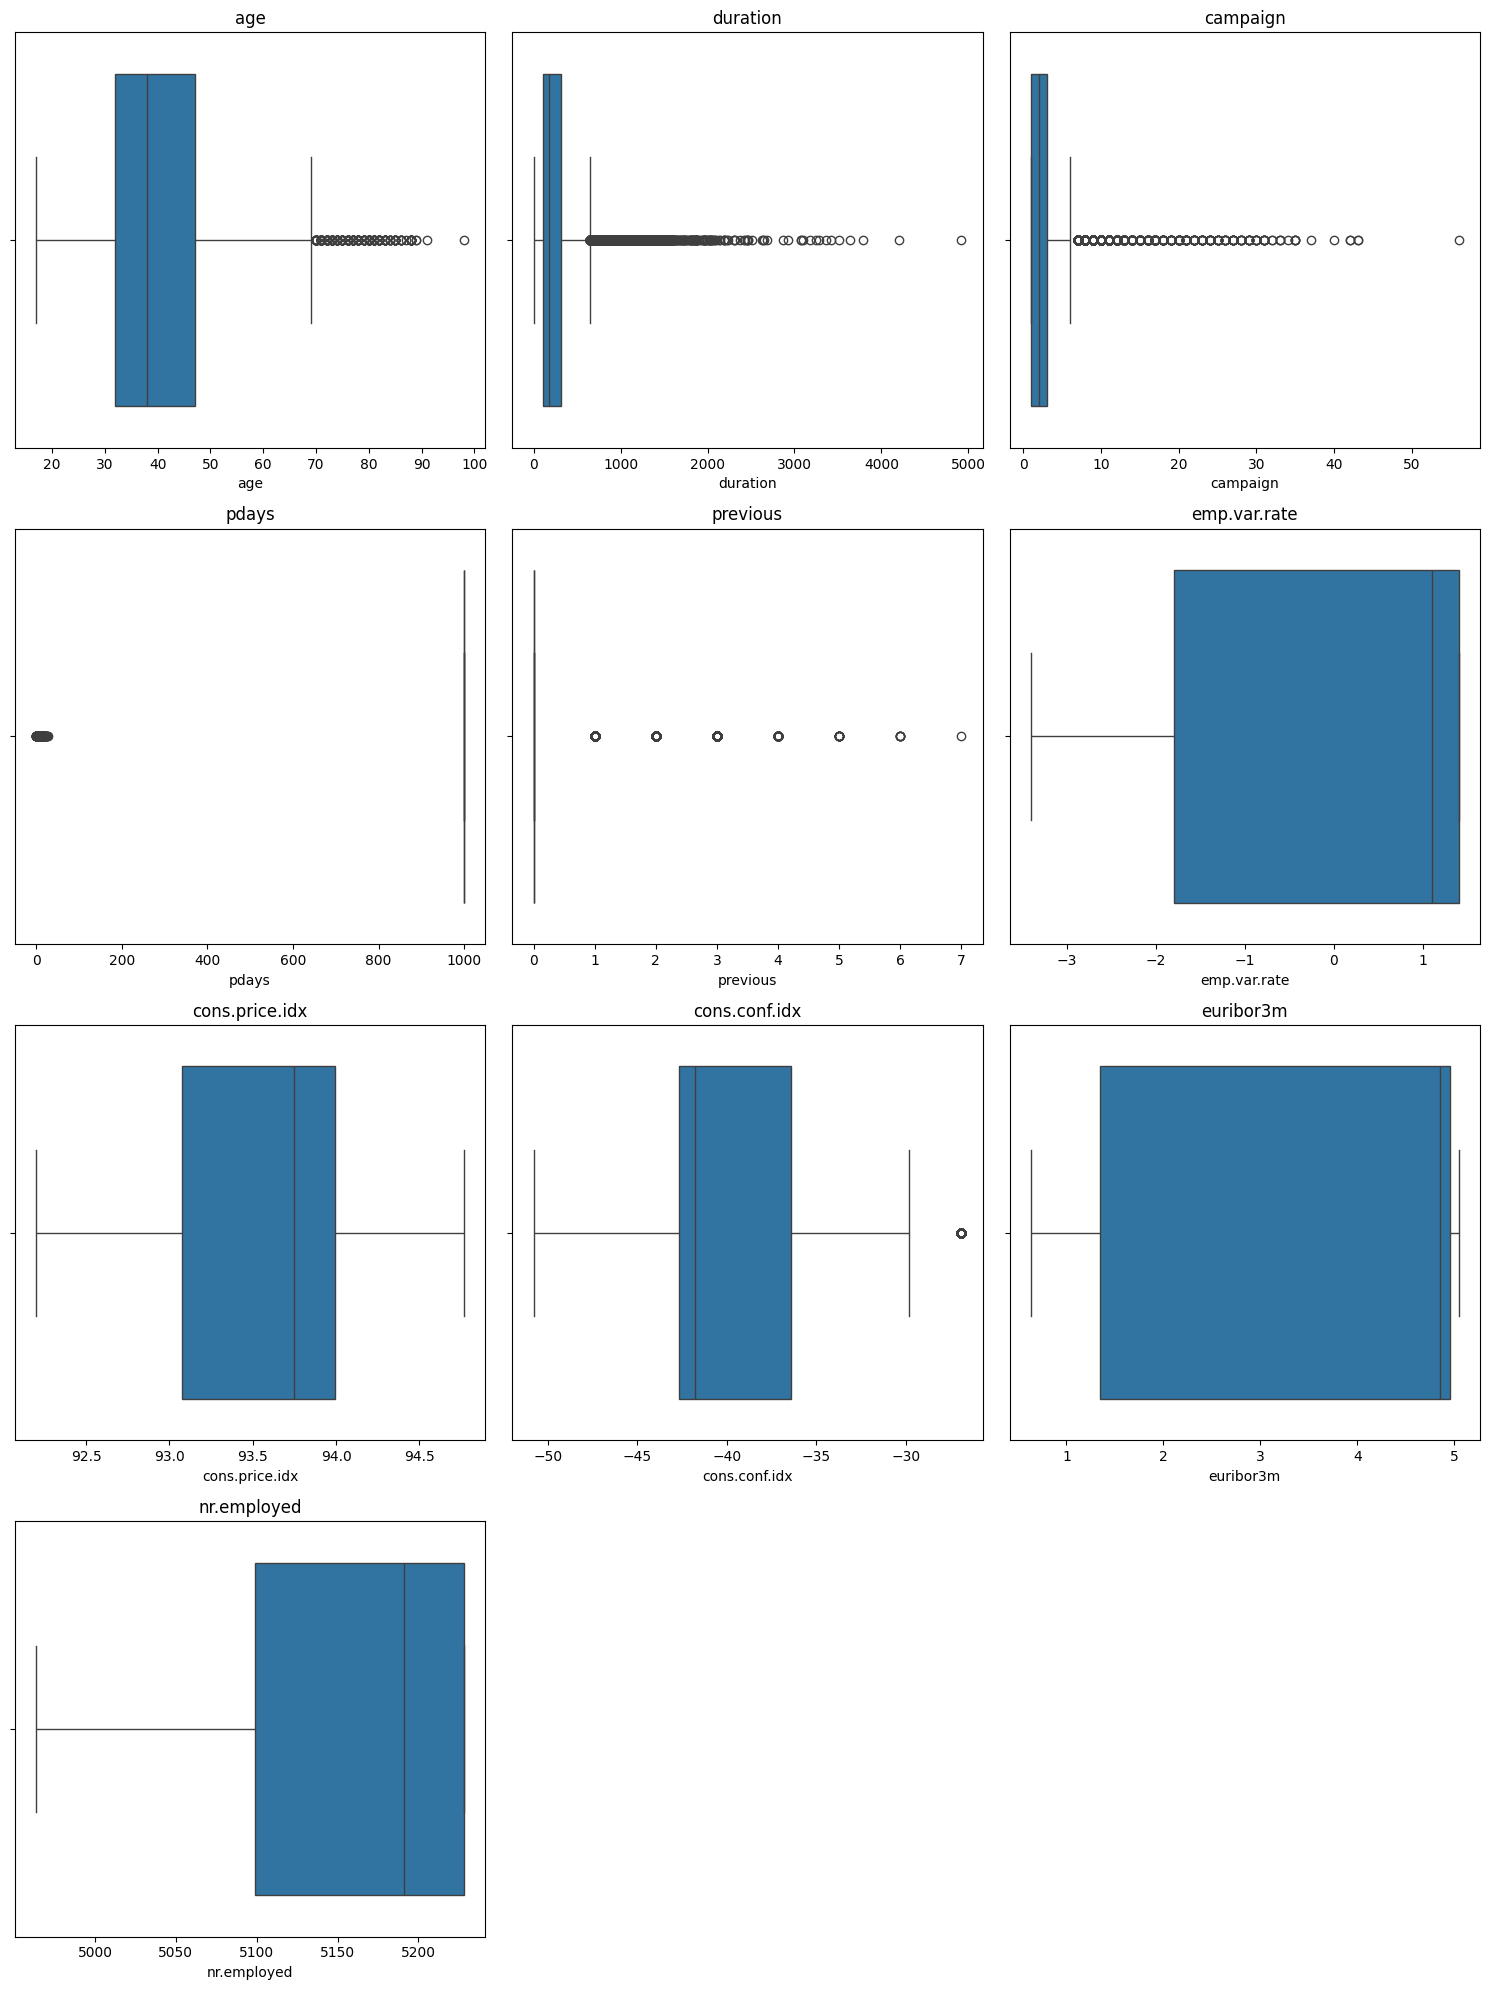

In [207]:
#визуализация с помощью boxplota
import math
n_cols_plot = 3
n_rows = math.ceil(len(num_cols) / n_cols_plot)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols_plot, i + 1) 
    sns.boxplot(x=Xf_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [208]:
#возьмем модель с LE, тк у нее больше accuracy, чем у one-hot encoding

# Считаю границы IQR по исходным числовым данным (Xf_train)

Q1 = Xf_train[num_cols].quantile(0.25)
Q3 = Xf_train[num_cols].quantile(0.75)
IQR = Q3 - Q1

lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR

# 2. Создаем маску
mask_clean = ~((Xf_train[num_cols] < lb) | (Xf_train[num_cols] > ub)).any(axis=1)


X_train_le_no_outliers = Xf_train_le[mask_clean] 
y_train_no_outliers = y_train[mask_clean]

print(f"Было строк: {Xf_train_le.shape[0]}")
print(f"Стало строк: {X_train_le_no_outliers.shape[0]}")
print(f"Удалено выбросов: {Xf_train_le.shape[0] - X_train_le_no_outliers.shape[0]}")

# 4. О
model_rf_clean_le = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_clean_le.fit(X_train_le_no_outliers, y_train_no_outliers)

# Проверяем на Xf_test_le в которой присутствуют выбросы
y_pred_clean_le = model_rf_clean_le.predict(Xf_test_le)

print(f'Accuracy LE без выбросов: {accuracy_score(y_test, y_pred_clean_le)}')

Было строк: 32950
Стало строк: 24269
Удалено выбросов: 8681
Accuracy LE без выбросов: 0.9099295945617868


5. Масштабирование признаков (2 балла)

- Примените StandardScaler или MinMaxScaler только к train выборке

- Обучите модель на данных с масштабированными признаками и на тестовой выборке оцените accuracy


In [209]:
# так как accuracy упал после удаления выбросов, возму выборку Xf_train_le с выбросами

scaler = StandardScaler()

X_train_scaled = Xf_train_le.copy()
X_test_scaled = Xf_test_le.copy()

#обучаем
scaler.fit(X_train_scaled[num_cols])
#стандартизируем
X_train_scaled[num_cols] = scaler.transform(X_train_scaled[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test_scaled[num_cols])


model_rf_scaled = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_rf_scaled.predict(X_test_scaled)
print(f'Accuracy после масштабирования и без удаления выбросов: {accuracy_score(y_test, y_pred_scaled)}')

Accuracy после масштабирования и без удаления выбросов: 0.9201262442340374


6. Итоги (1 балл)

- Сравните модели и создайте таблицу с accuracy всех моделей.
- Сделайте выводы

In [210]:

results_data = {
    'Experiment': [
        '1. Baseline (Только числовые)', 
        '2. Label Encoding (LE)', 
        '3. One-Hot Encoding (OHE)', 
        '4. LE + Удаление выбросов (IQR)', 
        '5. LE + Масштабирование (StandardScaler)'
    ],
    'Accuracy': [
        0.9164,  # Из baseline
        0.9202,  # Лучший результат кодирования
        0.9164,  # OHE
        0.9099,  # Упало после удаления выбросов
        0.9201   # Практически не изменилось после скейлинга
    ]
}
results_df = pd.DataFrame(results_data)

results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("Итоговая таблица результатов:")
print(results_df)

Итоговая таблица результатов:
                                 Experiment  Accuracy
1                    2. Label Encoding (LE)    0.9202
4  5. LE + Масштабирование (StandardScaler)    0.9201
0             1. Baseline (Только числовые)    0.9164
2                 3. One-Hot Encoding (OHE)    0.9164
3           4. LE + Удаление выбросов (IQR)    0.9099


#### Лучшая модель получилась при использовании всех данных (включая выбросы) и Label Encoding для категорий. Дальнейшие усложнения (удаление выбросов и масштабирование) не принесли пользы для Random Forest в этой задаче.